In [2]:
import os
import ast
import json
import pickle
import warnings
import numpy as np
import pandas as pd
import xarray as xr
import proplot as pplt
from matplotlib.lines import Line2D
warnings.filterwarnings('ignore')
pplt.rc.update({
    'savefig.dpi':900,
    'savefig.bbox':'tight',
    'savefig.pad_inches':0.02,
    'tick.minor':False,
    'font.size':9,
    'label.size':9,
    'tick.labelsize':9,
    'title.size':9,
    'abc.size':9,
    'legend.fontsize':9,
    'suptitle.size':9,
    'leftlabelsize':9,
    'toplabelsize':9,
    'leftlabel.weight':'normal',
    'toplabel.weight':'normal',
    'reso':'xx-hi'})

In [3]:
with open('../scripts/configs.json', 'r', encoding='utf-8') as f:
    CONFIGS = json.load(f)
SPLITSDIR    = CONFIGS['filepaths']['splits']
WEIGHTSDIR   = CONFIGS['filepaths']['weights']
MODELSDIR    = CONFIGS['filepaths']['models']
PREDSDIR     = CONFIGS['filepaths']['predictions']
RAWDIR       = CONFIGS['filepaths']['raw']
MODELS       = CONFIGS['experiments']
LATRANGE     = CONFIGS['domain']['latrange']
LONRANGE     = CONFIGS['domain']['lonrange']
FIELDVARS    = MODELS['sr']['runs']['sr_gauss']['fieldvars']
NNSEEDS      = MODELS['nn']['seeds']
SRSEEDS      = MODELS['sr']['seeds']
OPTIMIZEDEQS = MODELS['sr']['optimizedeqs']
SPLIT        = 'test'
NBINS        = 20
MINSAMPLES   = 50
ORDER        = ['sr_med', 'sr_hi', 'nn_gauss']
SRFUNCTIONS  = {
    'cube':lambda x:x**3, 'square':lambda x:x**2, 'neg':lambda x:-x,
    'sqrt':np.sqrt, 'exp':np.exp, 'log':np.log, 'abs':np.abs,
    'max':np.maximum, 'min':np.minimum}
COLORS = {}
LABELS = {}
for name, config in {**MODELS['nn']['runs'], **OPTIMIZEDEQS}.items():
    COLORS[name] = config['color']
    LABELS[name] = config['description']
KWMAP = dict(coast=True, latlim=LATRANGE, lonlim=LONRANGE,
             latlines=[10, 15, 20], lonlines=[65, 75, 85], grid=False)

In [4]:
def kernel_integrate(fields, weights, dsig, mask=None):
    w = fields * weights[None, :, :] * dsig[None, None, :]
    if mask is not None:
        w = w * mask[:, None, :]
    return w.sum(axis=2)

def to_phys(norm):
    return np.expm1(tpstd * np.maximum(0.0, np.asarray(norm, dtype=float)))

def eval_form(form, variables, constants):
    ns = dict(SRFUNCTIONS)
    ns.update(variables)
    ns.update(constants)
    return np.asarray(eval(form, {'__builtins__': {}}, ns), dtype=float)

def used_predictors(form, candidates):
    names = {n.id for n in ast.walk(ast.parse(form, mode='eval')) if isinstance(n, ast.Name)}
    return [c for c in candidates if c in names]

def r2(ytrue, ypred):
    mask = np.isfinite(ytrue) & np.isfinite(ypred)
    o, p = ytrue[mask], ypred[mask]
    return 1 - np.sum((o - p)**2) / np.sum((o - o.mean())**2)

def bin_1d(x, z, nbins=NBINS, minsamples=MINSAMPLES, plo=1, phi=99):
    finite = np.isfinite(x) & np.isfinite(z)
    x, z = x[finite], z[finite]
    edges = np.linspace(*np.percentile(x, [plo, phi]), nbins + 1)
    n = len(edges) - 1
    xi = np.clip(np.digitize(x, edges) - 1, 0, n - 1)
    counts = np.bincount(xi, minlength=n)
    sums = np.bincount(xi, weights=z, minlength=n)
    return 0.5 * (edges[:-1] + edges[1:]), np.where(counts >= minsamples, sums / counts, np.nan), counts

def bin_2d(x, y, z, nbins=NBINS, minsamples=MINSAMPLES, plo=1, phi=99):
    finite = np.isfinite(x) & np.isfinite(y) & np.isfinite(z)
    x, y, z = x[finite], y[finite], z[finite]
    xedges = np.linspace(*np.percentile(x, [plo, phi]), nbins + 1)
    yedges = np.linspace(*np.percentile(y, [plo, phi]), nbins + 1)
    xi = np.clip(np.digitize(x, xedges) - 1, 0, nbins - 1)
    yi = np.clip(np.digitize(y, yedges) - 1, 0, nbins - 1)
    idx = xi * nbins + yi
    counts = np.bincount(idx, minlength=nbins * nbins).reshape(nbins, nbins)
    sums = np.bincount(idx, weights=z, minlength=nbins * nbins).reshape(nbins, nbins)
    return (0.5 * (xedges[:-1] + xedges[1:]), 0.5 * (yedges[:-1] + yedges[1:]),
            np.where(counts >= minsamples, sums / counts, np.nan), counts)

def load_pred(name, split=SPLIT):
    path = os.path.join(PREDSDIR, f'{name}_{split}_predictions.nc')
    if not os.path.exists(path):
        return None
    with xr.open_dataset(path, engine='h5netcdf') as ds:
        da = ds['tp'].load()
    if 'seed' in da.dims:
        da = da.mean('seed')
    if 'complexity' in da.dims:
        da = da.isel(complexity=0)
    pred = da.transpose('time', 'lat', 'lon').values.ravel()
    return pred if pred.shape[0] == obsflat.shape[0] else None

def load_pareto(run, seeds=SRSEEDS):
    frames = []
    for seed in seeds:
        path = os.path.join(MODELSDIR, 'sr', f'{run}_{seed}_equations.csv')
        if os.path.exists(path):
            df = pd.read_csv(path)
            df['seed'] = seed
            frames.append(df)
    if not frames:
        return None
    df = pd.concat(frames, ignore_index=True)
    return df.groupby('complexity').agg(
        loss=('loss', 'mean'), equation=('equation', 'first')).reset_index()

def to_map(flat):
    return np.nanmean(flat.reshape(ntime, nlat, nlon), axis=0)

In [5]:
with open(os.path.join(SPLITSDIR, 'stats.json'), 'r', encoding='utf-8') as f:
    stats = json.load(f)
tpmean = float(stats['tp_mean'])
tpstd  = float(stats['tp_std'])

def flatten(da):
    if 'time' in da.dims:
        return da.transpose('time', 'lat', 'lon').values.ravel()
    return np.tile(da.values, (ntime, 1, 1)).ravel()

with xr.open_dataset(os.path.join(SPLITSDIR, f'norm_{SPLIT}.h5'), engine='h5netcdf') as ds:
    ntime, nlat, nlon = ds.sizes['time'], ds.sizes['lat'], ds.sizes['lon']
    nsig = ds.sizes.get('sig', 1)
    lat  = ds['lat'].values
    lon  = ds['lon'].values
    dsig = ds['dsig'].values
    sig  = ds['sig'].values if 'sig' in ds else np.linspace(0.5, 1.0, nsig)
    fields   = np.stack([ds[v].transpose('time', 'lat', 'lon', 'sig').values.reshape(-1, nsig)
                         for v in FIELDVARS], axis=1)
    surfmask = (ds['surfmask'].transpose('time', 'lat', 'lon', 'sig').values.reshape(-1, nsig)
                if 'surfmask' in ds else None)
    blnorm  = flatten(ds['bl'])
    lfnorm  = flatten(ds['lf'])
    shfnorm = flatten(ds['shf'])
    lhfnorm = flatten(ds['lhf'])

kernels = []
for seed in NNSEEDS:
    wpath = os.path.join(WEIGHTSDIR, f'nn_gauss_{seed}_weights.nc')
    if os.path.exists(wpath):
        with xr.open_dataset(wpath, engine='h5netcdf') as ds:
            kernels.append(ds['k'].values)
kmean = np.mean(kernels, axis=0) if kernels else None
ki = (np.mean([kernel_integrate(fields, k, dsig, surfmask) for k in kernels], axis=0)
      if kernels else fields.mean(axis=2))
rhk, thetaek, thetaestark = ki[:, 0], ki[:, 1], ki[:, 2]

with xr.open_dataset(os.path.join(SPLITSDIR, f'{SPLIT}.h5'), engine='h5netcdf') as ds:
    obsflat = ds.tp.transpose('time', 'lat', 'lon').values.ravel()
    lfraw   = flatten(ds['lf'])
    shfraw  = flatten(ds['shf'])
    lhfraw  = flatten(ds['lhf'])
    sdoraw  = flatten(ds['sdo']) if 'sdo' in ds else None
    sefraw  = flatten(ds['sef']) if 'sef' in ds else None
    seraw   = flatten(ds['se'])  if 'se'  in ds else None
    months  = np.tile(ds.time.dt.month.values[:, None, None]
                      * np.ones((1, nlat, nlon)), 1).ravel().astype(int)

semap = None
sepath = os.path.join(RAWDIR, 'ERA5_surface_elevation.nc')
if os.path.exists(sepath):
    with xr.open_dataset(sepath, engine='netcdf4') as ds:
        sevar = list(ds.data_vars)[0]
        se = ds[sevar]
        if 'time' in se.dims:
            se = se.isel(time=0)
        se    = se.interp(lat=lat, lon=lon, method='linear')
        semap = se.values.astype(np.float32)
seflat = np.tile(semap, (ntime, 1, 1)).ravel() if semap is not None else seraw

regpath = os.path.join(MODELSDIR, 'sr', 'optimized_equations.pkl')
if os.path.exists(regpath):
    with open(regpath, 'rb') as f:
        SR_REGISTRY = pickle.load(f)
else:
    SR_REGISTRY = {}

VARS = {'rh': rhk, 'thetae': thetaek, 'thetaestar': thetaestark,
        'bl': blnorm, 'lf': lfnorm, 'shf': shfnorm, 'lhf': lhfnorm}

MODELPRED = {}
for name, config in OPTIMIZEDEQS.items():
    entry     = SR_REGISTRY.get(name, {})
    form      = entry.get('form', config['form'])
    constants = entry.get('constants', config['init'])
    pnames    = used_predictors(form, VARS.keys())
    if all(p in VARS for p in pnames):
        MODELPRED[name] = to_phys(eval_form(form, {p: VARS[p] for p in pnames}, constants))

for name in MODELS['nn']['runs']:
    pred = load_pred(name)
    if pred is not None:
        MODELPRED[name] = pred

valid = np.isfinite(obsflat)
for arr in VARS.values():
    valid &= np.isfinite(arr)

print(f'Valid: {valid.sum():,} | Loaded: {sorted(MODELPRED.keys())}')
for name in ORDER:
    if name in MODELPRED:
        print(f'  {LABELS.get(name, name):20s}  R\u00b2={r2(obsflat[valid], MODELPRED[name][valid]):.3f}')
    else:
        print(f'  {LABELS.get(name, name):20s}  \u2014 not available')

Valid: 1,437,408 | Loaded: ['sr_bl', 'sr_hi', 'sr_lo', 'sr_med']
  SR-MED                R²=0.329
  SR-HI                 R²=0.353
  NN-GAUSS              — not available


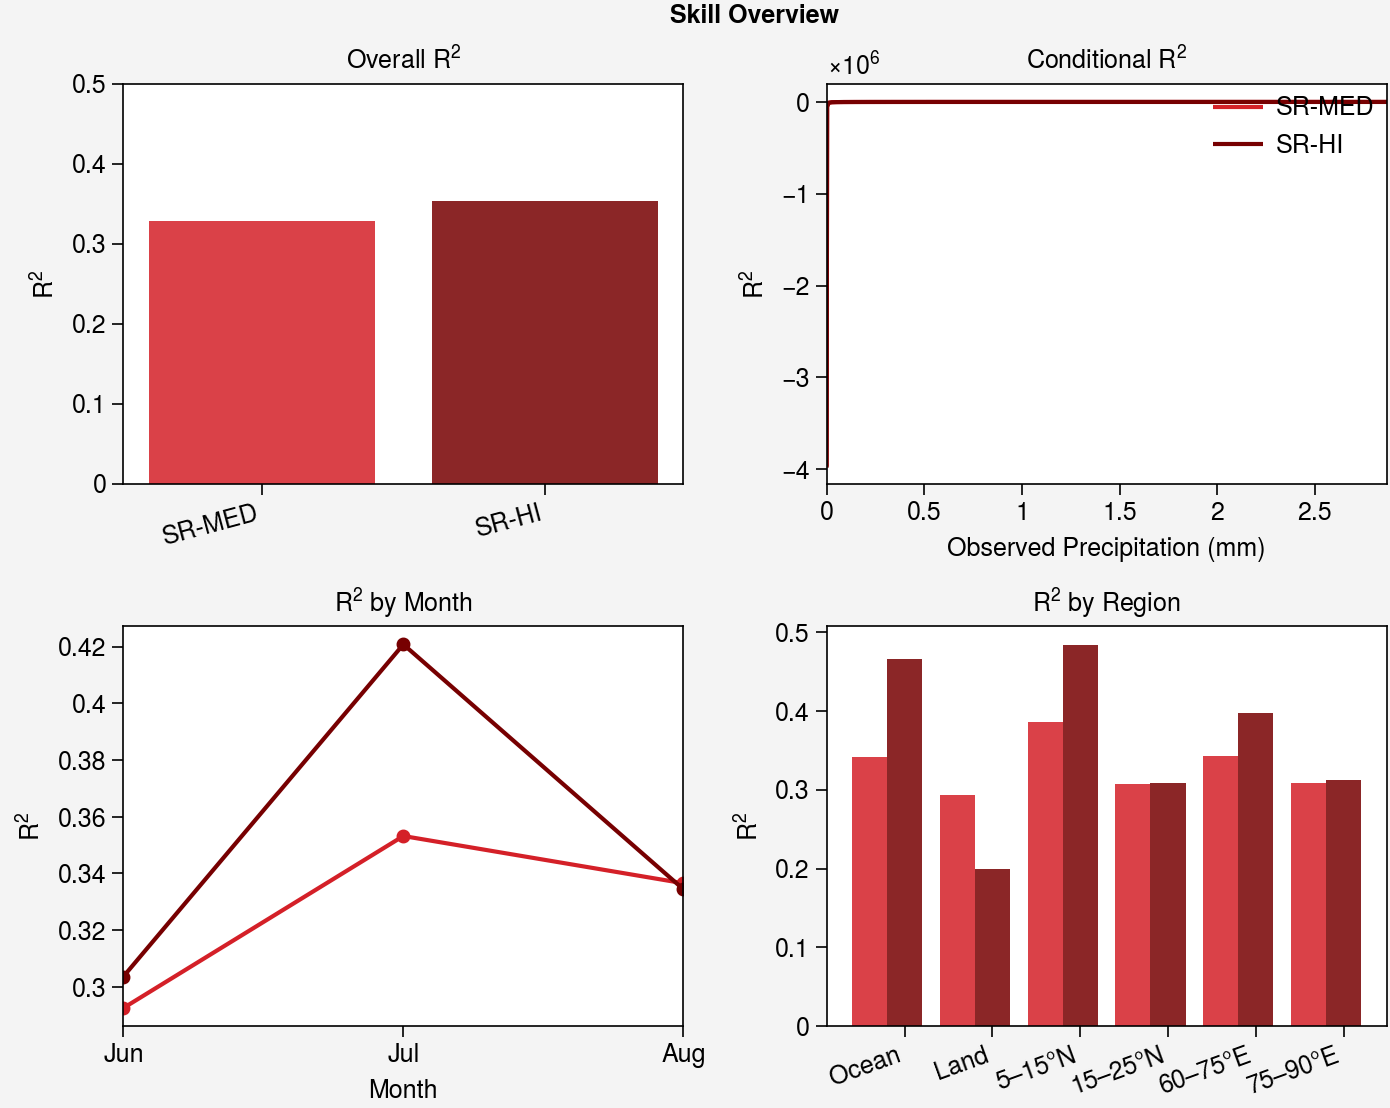

In [6]:
# Goal: How much overall skill does each model capture?
obs   = obsflat[valid]
names = [n for n in ORDER if n in MODELPRED]

edges = np.percentile(obs, np.linspace(0, 95, 16))
xc    = 0.5 * (edges[:-1] + edges[1:])
idxs  = np.clip(np.digitize(obs, edges) - 1, 0, 14)
r2vals = {LABELS[n]: r2(obs, MODELPRED[n][valid]) for n in names}

mons = months[valid]
latv = np.tile(lat[None, :, None], (ntime, 1, nlon)).ravel()[valid]
lonv = np.tile(lon[None, None, :], (ntime, nlat, 1)).ravel()[valid]
lfv  = lfraw[valid]
regions = {
    'Ocean':      lfv < 0.1,
    'Land':       lfv > 0.9,
    '5\u201315\u00b0N':  (latv >= 5) & (latv < 15),
    '15\u201325\u00b0N': (latv >= 15) & (latv <= 25),
    '60\u201375\u00b0E': (lonv >= 60) & (lonv < 75),
    '75\u201390\u00b0E': (lonv >= 75) & (lonv <= 90)}

fig, axs = pplt.subplots(nrows=2, ncols=2, refwidth=2.8, refheight=2, share=False)

clrs = [COLORS[n] for n in names]
axs[0].bar(np.arange(len(r2vals)), list(r2vals.values()), color=clrs, alpha=0.85)
axs[0].format(ylabel=r'$R^2$', xticks=np.arange(len(r2vals)),
              xticklabels=list(r2vals.keys()), xrotation=15,
              title=r'Overall $R^2$', grid=False, ylim=(0, 0.5))

axs[1].axhline(0, color='gray', linewidth=0.8, linestyle='--')
for name in names:
    r2bins = [r2(obs[idxs == i], MODELPRED[name][valid][idxs == i])
              if (idxs == i).sum() >= 200 else np.nan for i in range(15)]
    axs[1].plot(xc, r2bins, color=COLORS[name], linewidth=1.5, label=LABELS[name])
axs[1].format(xlabel='Observed Precipitation (mm)', ylabel=r'$R^2$',
              title=r'Conditional $R^2$', grid=False)
axs[1].legend(loc='ur', ncols=1, frame=False)

xmon = np.array([6, 7, 8])
for name in names:
    pred = MODELPRED[name][valid]
    axs[2].plot(xmon, [r2(obs[mons == m], pred[mons == m]) for m in xmon],
                color=COLORS[name], linewidth=1.5, marker='o', markersize=4)
axs[2].format(xlabel='Month', ylabel=r'$R^2$', xticks=xmon,
              xticklabels=['Jun', 'Jul', 'Aug'], title=r'$R^2$ by Month', grid=False)

xreg  = np.arange(len(regions))
width = 0.8 / max(len(names), 1)
for i, name in enumerate(names):
    pred = MODELPRED[name][valid]
    axs[3].bar(xreg + i * width,
               [r2(obs[mask], pred[mask]) for mask in regions.values()],
               width=width, color=COLORS[name], alpha=0.85)
axs[3].format(ylabel=r'$R^2$', xticks=xreg + width,
              xticklabels=list(regions.keys()), xrotation=20,
              title=r'$R^2$ by Region', grid=False)

fig.format(suptitle='Skill Overview')
pplt.show()
fig.save('../figs/fig_eval_1.jpg')

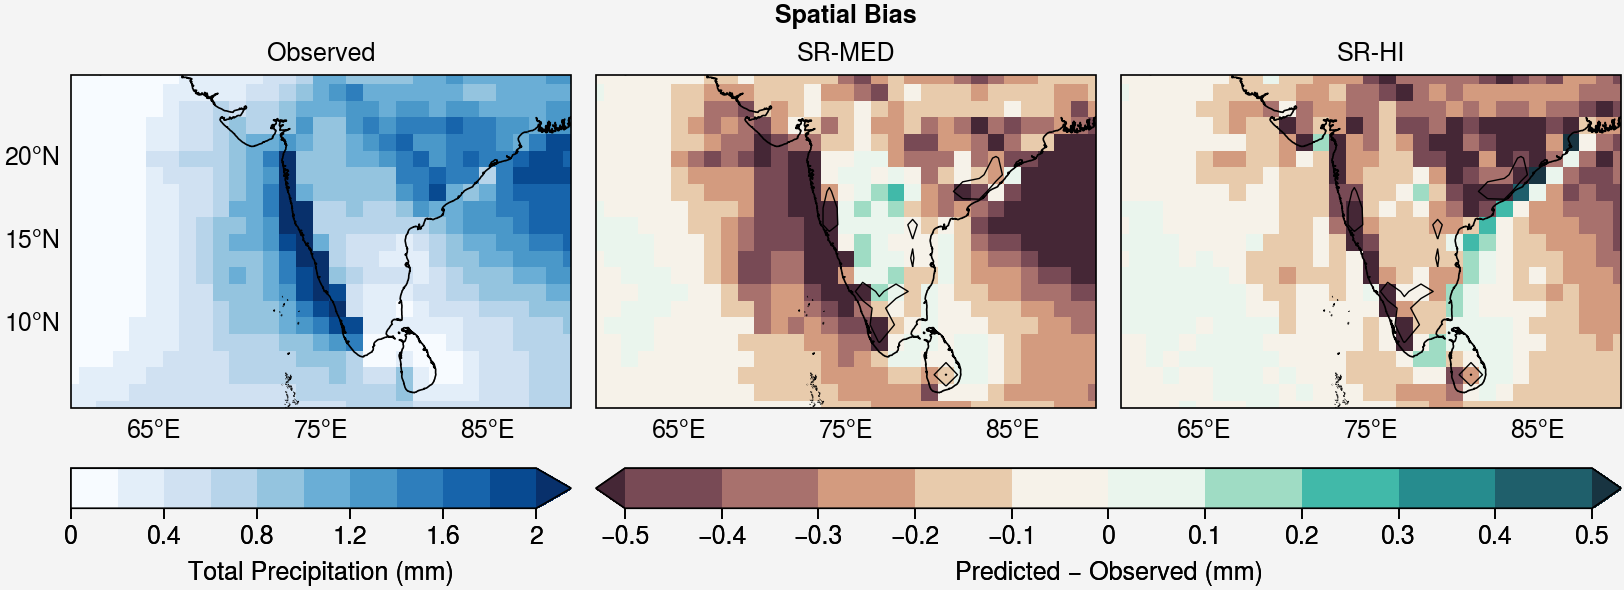

In [7]:
# Goal: Where do models fail geographically?
obsmap = to_map(obsflat)
names  = [n for n in ORDER if n in MODELPRED]
panels = ['obs'] + names
ncols  = len(panels)
sdomap = sdoraw.reshape(ntime, nlat, nlon)[0] if sdoraw is not None else None

fig, axs = pplt.subplots(nrows=1, ncols=ncols, proj='cyl', refwidth=2.5, share=False)
axsf = np.atleast_1d(axs).ravel()
mc = mr = None
for i, (ax, panel) in enumerate(zip(axsf, panels)):
    if panel == 'obs':
        mc = ax.pcolormesh(lon, lat, obsmap, cmap='Blues', vmin=0, vmax=2, extend='max')
        ax.format(title='Observed')
    else:
        rmap = to_map(MODELPRED[panel]) - obsmap
        mr = ax.pcolormesh(lon, lat, rmap, cmap='DryWet', vmin=-0.5, vmax=0.5, extend='both')
        if sdomap is not None:
            ax.contour(lon, lat, sdomap, levels=[100, 300, 500], colors='k', linewidths=0.5)
        ax.format(title=LABELS.get(panel, panel))
    ax.format(latlabels='l' if i == 0 else False, lonlabels='b', **KWMAP)

if mc:
    fig.colorbar(mc, loc='b', label='Total Precipitation (mm)', col=1)
if mr:
    fig.colorbar(mr, loc='b', label='Predicted \u2212 Observed (mm)', col=(2, ncols))
fig.format(suptitle='Spatial Bias')
pplt.show()
fig.save('../figs/fig_eval_2.jpg')

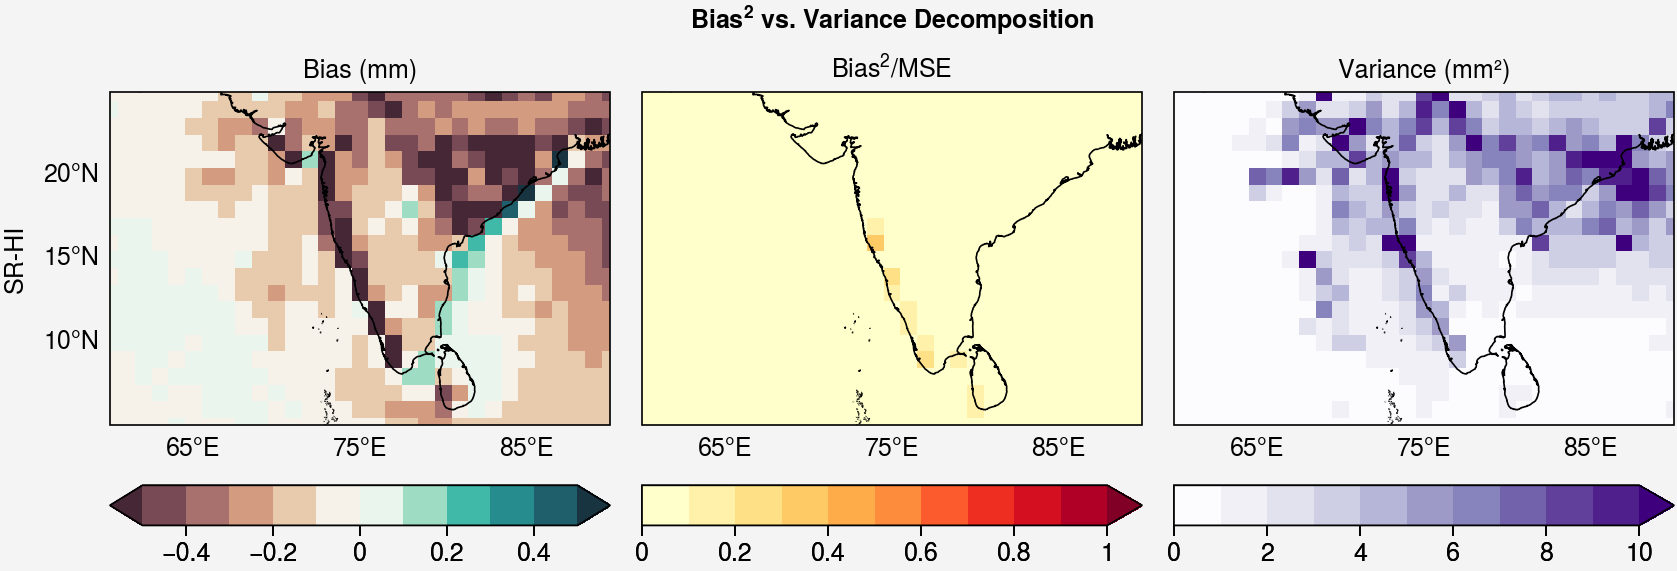

In [8]:
# Goal: Is error systematic (bias) or random (variance)?
names_bv = [n for n in ['sr_hi', 'nn_gauss'] if n in MODELPRED]
if names_bv:
    obs3d = obsflat.reshape(ntime, nlat, nlon)
    nrows_bv = len(names_bv)

    all_panels = []
    vmax_var = 0
    for name in names_bv:
        pred3d   = MODELPRED[name].reshape(ntime, nlat, nlon)
        bias_map = np.nanmean(pred3d - obs3d, axis=0)
        mse_map  = np.nanmean((pred3d - obs3d)**2, axis=0)
        var_map  = mse_map - bias_map**2
        b2frac   = np.where(mse_map > 0, bias_map**2 / mse_map, np.nan)
        vmax_var = max(vmax_var, float(np.nanpercentile(var_map, 98)))
        all_panels.append((name, bias_map, b2frac, var_map))

    fig, axs = pplt.subplots(nrows=nrows_bv, ncols=3, proj='cyl', refwidth=2.5, share=False)
    axsf = np.atleast_1d(axs).ravel()
    for row, (name, bias_map, b2frac, var_map) in enumerate(all_panels):
        specs = [('Bias (mm)', bias_map, 'DryWet', -0.5, 0.5, 'both'),
                 (r'Bias$^2$/MSE', b2frac, 'YlOrRd', 0, 1, 'max'),
                 ('Variance (mm\u00b2)', var_map, 'Purples', 0, vmax_var, 'max')]
        for col, (title, arr, cmap, vmin, vmax, extend) in enumerate(specs):
            ax = axsf[row * 3 + col]
            m  = ax.pcolormesh(lon, lat, arr, cmap=cmap, vmin=vmin, vmax=vmax, extend=extend)
            ax.format(title=title, latlabels='l' if col == 0 else False,
                      lonlabels='b', **KWMAP)
            if row == 0:
                fig.colorbar(m, loc='b', col=col + 1)

    fig.format(suptitle=r'Bias$^2$ vs. Variance Decomposition',
               rowlabels=[LABELS.get(n, n) for n in names_bv])
    pplt.show()
    fig.save('../figs/fig_eval_3.jpg')
else:
    print('No models available for bias/variance decomposition')

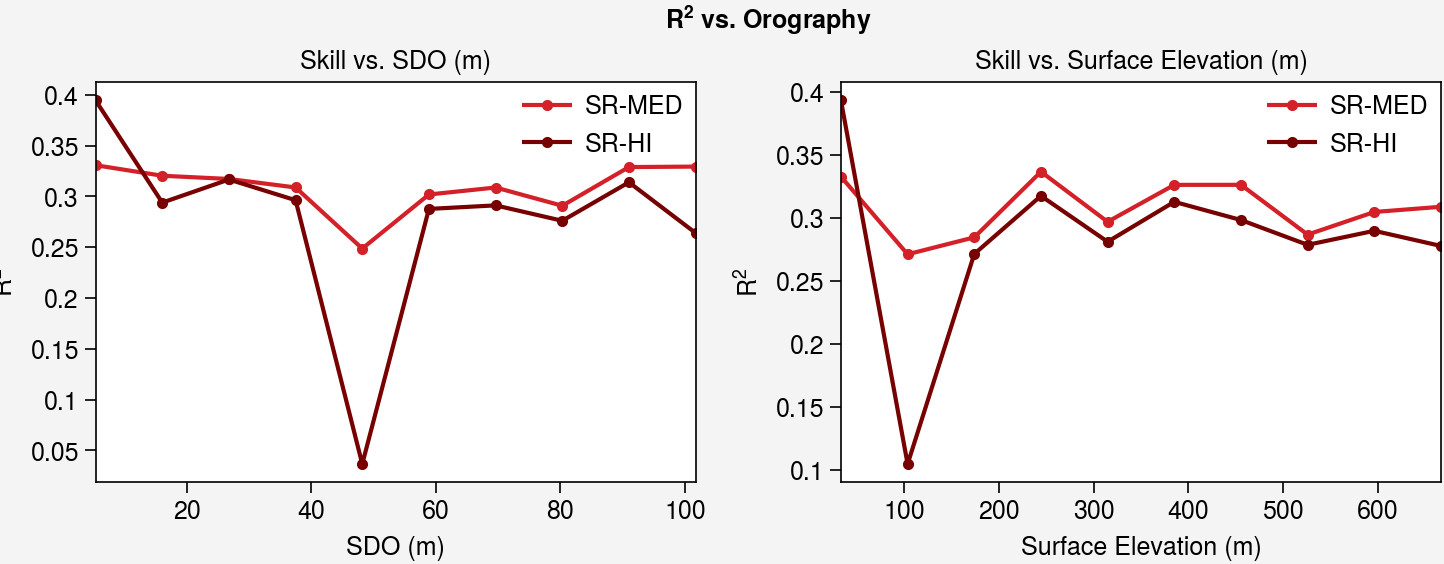

In [9]:
# Goal: Does skill degrade with terrain complexity?
names_orog = [n for n in ORDER if n in MODELPRED]
obs = obsflat[valid]

orogpanels = []
if sdoraw is not None:
    orogpanels.append(('SDO (m)', sdoraw[valid]))
if seflat is not None:
    orogpanels.append(('Surface Elevation (m)', seflat[valid]))

if orogpanels:
    fig, axs = pplt.subplots(nrows=1, ncols=len(orogpanels),
                              refwidth=3, refheight=2, share=False)
    axsf = np.atleast_1d(axs).ravel()
    for ax, (oroglabel, orog) in zip(axsf, orogpanels):
        lo, hi = np.percentile(orog, [2, 98])
        edges  = np.linspace(lo, hi, 11)
        xc     = 0.5 * (edges[:-1] + edges[1:])
        idxs   = np.clip(np.digitize(orog, edges) - 1, 0, 9)
        for name in names_orog:
            pred = MODELPRED[name][valid]
            r2s  = [r2(obs[idxs == i], pred[idxs == i])
                    if (idxs == i).sum() >= 500 else np.nan for i in range(10)]
            ax.plot(xc, r2s, color=COLORS[name], linewidth=1.5, marker='o',
                    markersize=3, label=LABELS[name])
        ax.format(xlabel=oroglabel, ylabel=r'$R^2$',
                  title=f'Skill vs. {oroglabel}', grid=False)
        ax.legend(loc='ur', ncols=1, frame=False)
    fig.format(suptitle=r'$R^2$ vs. Orography')
    pplt.show()
    fig.save('../figs/fig_eval_4.jpg')
else:
    print('No orography data available')

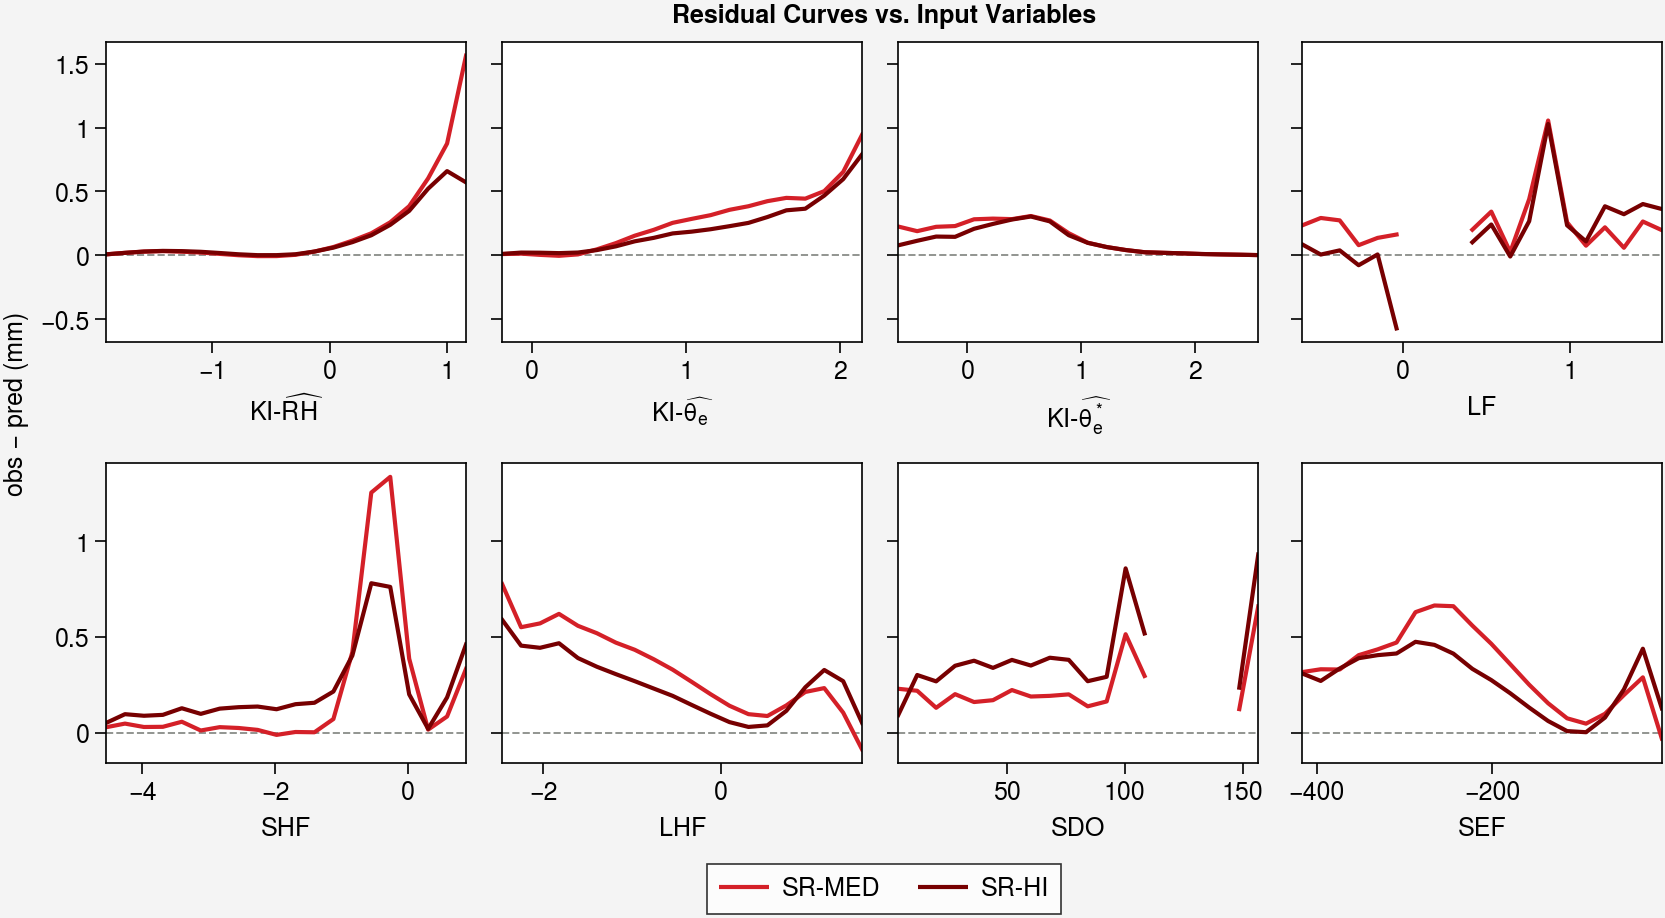

In [16]:
# Goal: Which input variables drive residual structure?
names_r = [n for n in ORDER if n in MODELPRED]
obs = obsflat[valid]

plotvars = [
    (rhk, r'KI-$\widehat{\mathrm{RH}}$'),
    (thetaek, r'KI-$\widehat{\theta_e}$'),
    (thetaestark, r'KI-$\widehat{\theta_e^*}$'),
    (lfnorm, 'LF'), (shfnorm, 'SHF'), (lhfnorm, 'LHF')]
if sdoraw is not None:
    plotvars.append((sdoraw, 'SDO'))
if sefraw is not None:
    plotvars.append((sefraw, 'SEF'))

ncols = min(4, len(plotvars))
nrows = -(-len(plotvars) // ncols)
fig, axs = pplt.subplots(nrows=nrows, ncols=ncols, refwidth=1.8, refheight=1.5,
                          sharex=False, sharey=True)
axsf = np.atleast_1d(axs).ravel()
for i, (ax, (varr, vlabel)) in enumerate(zip(axsf, plotvars)):
    ax.axhline(0, color='gray', linewidth=0.7, linestyle='--')
    for name in names_r:
        xc, residbin, _ = bin_1d(varr[valid], obs - MODELPRED[name][valid])
        ax.plot(xc, residbin, color=COLORS[name], linewidth=1.5)
    ax.format(grid=False, xlabel=vlabel,
              ylabel='obs \u2212 pred (mm)' if i % ncols == 0 else '')
for ax in axsf[len(plotvars):]:
    ax.set_visible(False)
handles = [Line2D([], [], color=COLORS[n], linewidth=1.5, label=LABELS[n]) for n in names_r]
fig.legend(handles, loc='b', ncols=len(names_r))
fig.format(suptitle='Residual Curves vs. Input Variables')
pplt.show()
fig.save('../figs/fig_eval_5.jpg')

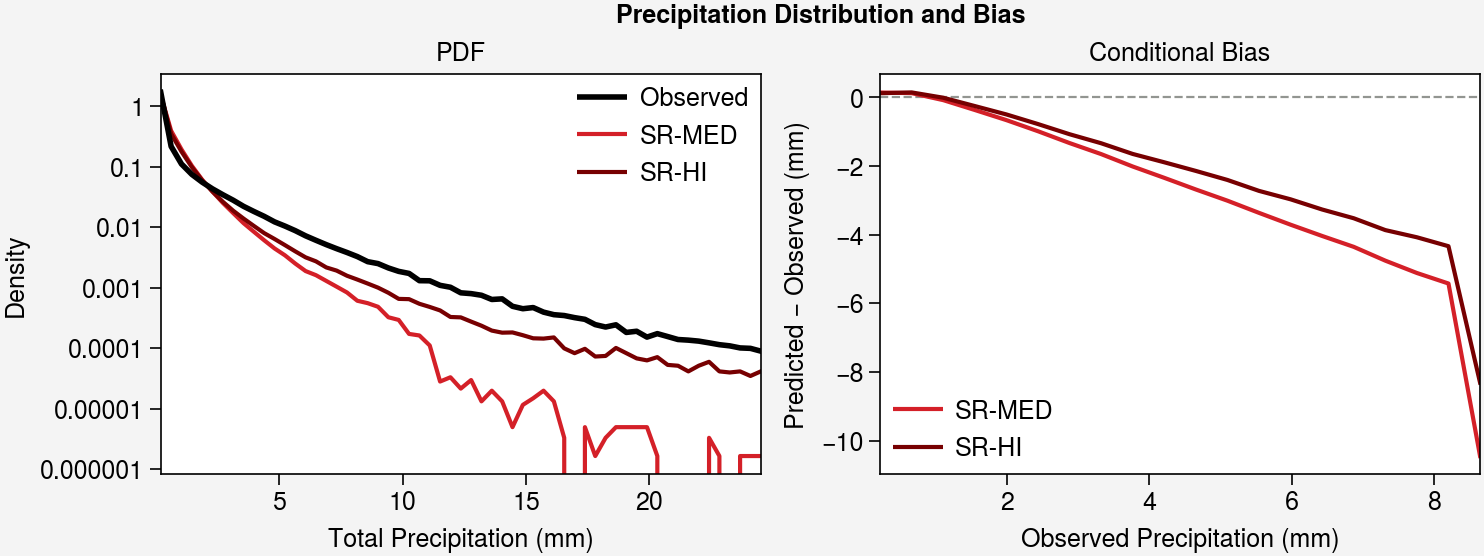

In [11]:
# Goal: Do models reproduce the precipitation distribution and intensity scaling?
names_p = [n for n in ORDER if n in MODELPRED]
obs = obsflat[valid]
hi  = np.percentile(obs[obs > 0], 99.9)
edges_pdf = np.linspace(0, hi, 60)
xc_pdf    = 0.5 * (edges_pdf[:-1] + edges_pdf[1:])

fig, axs = pplt.subplots(nrows=1, ncols=2, refwidth=3, refheight=2, share=False)

obshist, _ = np.histogram(obs, bins=edges_pdf, density=True)
axs[0].plot(xc_pdf, obshist, color='k', linewidth=2, label='Observed', zorder=6)
for name in names_p:
    predhist, _ = np.histogram(MODELPRED[name][valid], bins=edges_pdf, density=True)
    axs[0].plot(xc_pdf, predhist, color=COLORS[name], linewidth=1.5, label=LABELS[name])
axs[0].format(grid=False, xlabel='Total Precipitation (mm)', ylabel='Density',
              title='PDF', yscale='log')
axs[0].legend(loc='ur', ncols=1, frame=False)

xc_bias, _, _ = bin_1d(obs, obs, nbins=20, minsamples=100, plo=0, phi=99)
axs[1].axhline(0, color='gray', linewidth=0.8, linestyle='--')
for name in names_p:
    _, biasbin, _ = bin_1d(obs, MODELPRED[name][valid] - obs,
                           nbins=20, minsamples=100, plo=0, phi=99)
    axs[1].plot(xc_bias, biasbin, color=COLORS[name], linewidth=1.5, label=LABELS[name])
axs[1].format(grid=False, xlabel='Observed Precipitation (mm)',
              ylabel='Predicted \u2212 Observed (mm)', title='Conditional Bias')
axs[1].legend(loc='ll', ncols=1, frame=False)

fig.format(suptitle='Precipitation Distribution and Bias')
pplt.show()
fig.save('../figs/fig_eval_6.jpg')

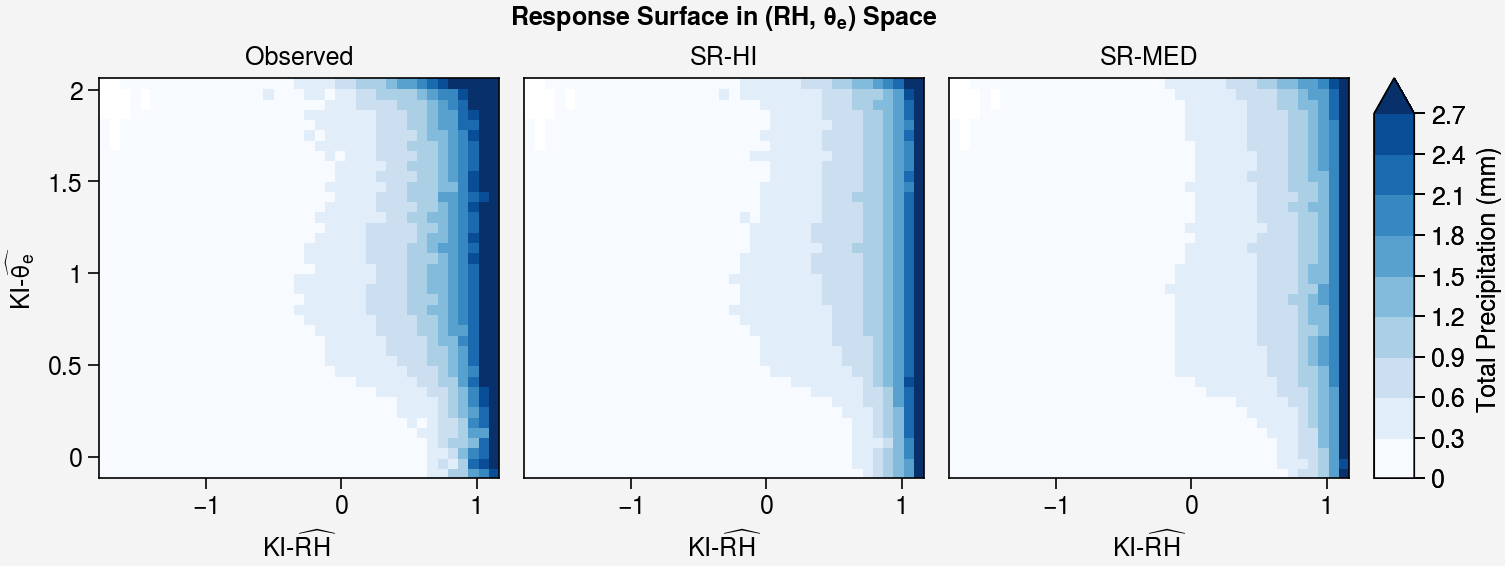

In [12]:
# Goal: How does SR-HI carve up the input space compared to observations and NN-GAUSS?
if 'sr_hi' not in SR_REGISTRY:
    print('sr_hi not in registry \u2014 skipping response surface')
else:
    rv, tv = rhk[valid], thetaek[valid]
    obs = obsflat[valid]

    xc_rt, yc_rt, obsbin_rt, _ = bin_2d(rv, tv, obs,
                                         nbins=39, minsamples=20, plo=2, phi=98)
    panels_rt = [('Observed', obsbin_rt)]
    if 'sr_hi' in MODELPRED:
        _, _, srbin_rt, _ = bin_2d(rv, tv, MODELPRED['sr_hi'][valid],
                                    nbins=39, minsamples=20, plo=2, phi=98)
        panels_rt.append(('SR-HI', srbin_rt))
    if 'sr_med' in MODELPRED:
        _, _, smbin_rt, _ = bin_2d(rv, tv, MODELPRED['sr_med'][valid],
                                    nbins=39, minsamples=20, plo=2, phi=98)
        panels_rt.append(('SR-MED', smbin_rt))
    if 'nn_gauss' in MODELPRED:
        _, _, nnbin_rt, _ = bin_2d(rv, tv, MODELPRED['nn_gauss'][valid],
                                    nbins=39, minsamples=20, plo=2, phi=98)
        panels_rt.append(('NN-GAUSS', nnbin_rt))

    fig, axs = pplt.subplots(nrows=1, ncols=len(panels_rt), refwidth=2, share=False)
    axsf = np.atleast_1d(axs).ravel()
    for i, (ax, (title, zb)) in enumerate(zip(axsf, panels_rt)):
        m = ax.pcolormesh(xc_rt, yc_rt, zb.T, cmap='Blues', vmin=0, vmax=3, extend='max')
        ax.format(grid=False, xlabel=r'KI-$\widehat{\mathrm{RH}}$',
                  ylabel=r'KI-$\widehat{\theta_e}$' if i == 0 else '',
                  title=title)
        if i > 0:
            ax.tick_params(axis='y', left=False, labelleft=False)
    fig.colorbar(m, loc='r', label='Total Precipitation (mm)')
    fig.format(suptitle=r'Response Surface in (RH, $\theta_e$) Space')
    pplt.show()
    fig.save('../figs/fig_eval_7.jpg')

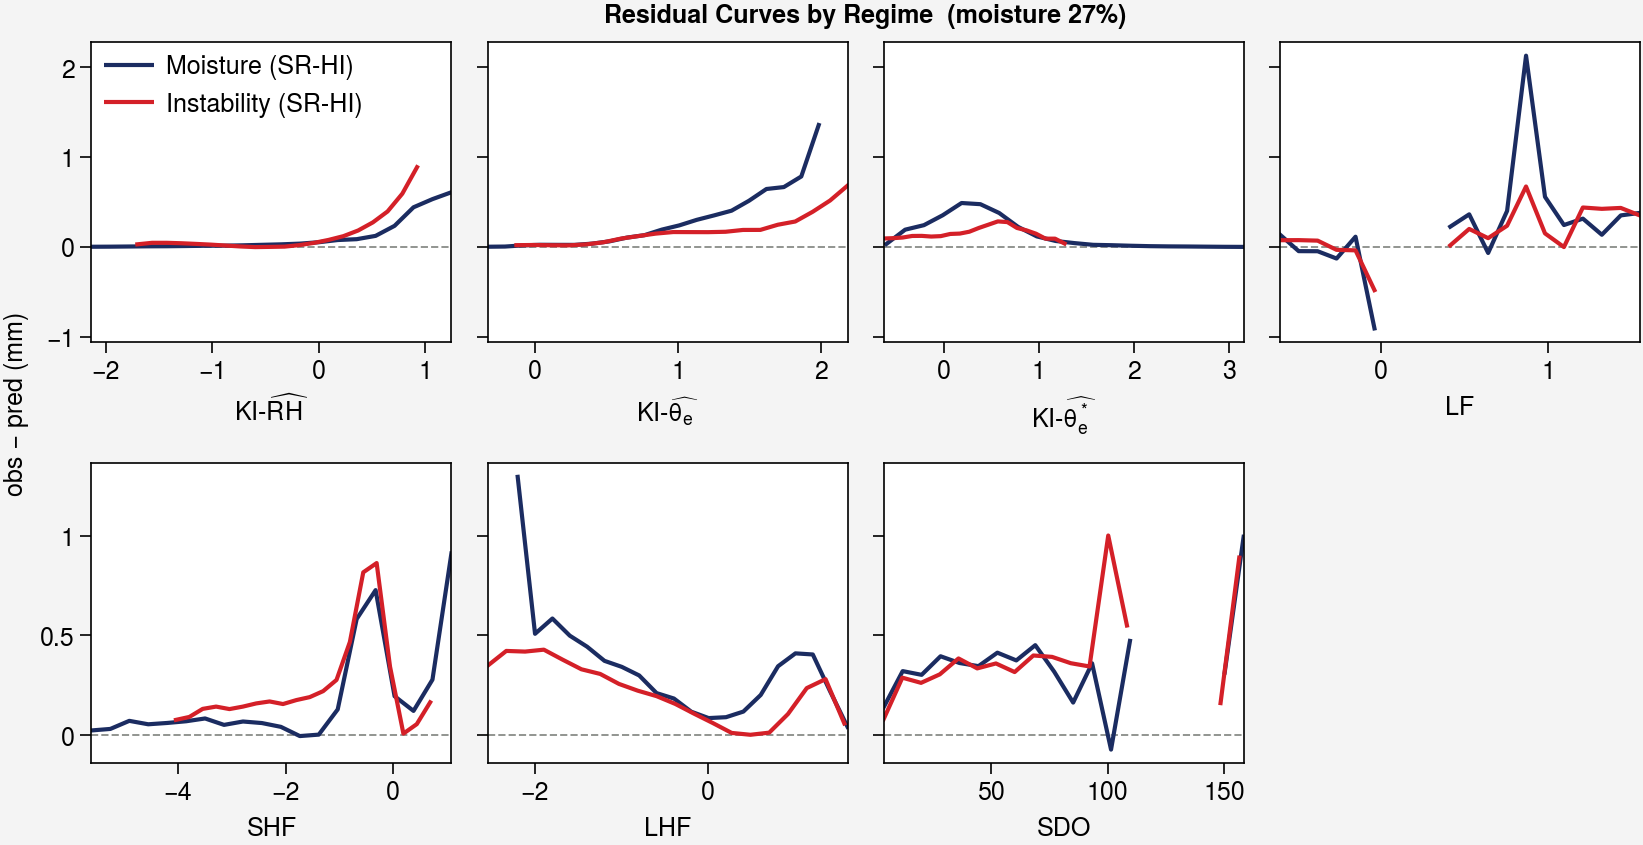

In [13]:
# Goal: Does the moisture/instability regime switch cause skill loss?
if 'sr_hi' not in MODELPRED:
    print('sr_hi not loaded \u2014 skipping regime analysis')
else:
    entry = SR_REGISTRY.get('sr_hi', {})
    c = entry.get('constants', OPTIMIZEDEQS['sr_hi']['init'])

    rv, tv, tsv   = rhk[valid], thetaek[valid], thetaestark[valid]
    lfv, shfv     = lfnorm[valid], shfnorm[valid]
    obs           = obsflat[valid]
    resid_hi      = obs - MODELPRED['sr_hi'][valid]
    has_nn        = 'nn_gauss' in MODELPRED
    resid_nn      = obs - MODELPRED['nn_gauss'][valid] if has_nn else None
    moisture_dom  = rv >= (tv + c['b'] * tsv + c['c'])

    plotfeats = [
        (rv,  r'KI-$\widehat{\mathrm{RH}}$'),
        (tv,  r'KI-$\widehat{\theta_e}$'),
        (tsv, r'KI-$\widehat{\theta_e^*}$'),
        (lfv, 'LF'), (shfv, 'SHF'), (lhfnorm[valid], 'LHF')]
    if sdoraw is not None:
        plotfeats.append((sdoraw[valid], 'SDO'))

    ncols = min(4, len(plotfeats))
    nrows = -(-len(plotfeats) // ncols)
    fig, axs = pplt.subplots(nrows=nrows, ncols=ncols, refwidth=1.8, refheight=1.5,
                              sharex=False, sharey=True)
    axsf = np.atleast_1d(axs).ravel()
    for i, (ax, (farr, flabel)) in enumerate(zip(axsf, plotfeats)):
        ax.axhline(0, color='gray', linewidth=0.7, linestyle='--')
        for mask, color in [(moisture_dom, '#1B2C61'), (~moisture_dom, '#D42028')]:
            xc, means, _ = bin_1d(farr[mask], resid_hi[mask])
            ax.plot(xc, means, color=color, linewidth=1.5)
            if has_nn:
                xc_nn, means_nn, _ = bin_1d(farr[mask], resid_nn[mask])
                ax.plot(xc_nn, means_nn, color=color, linewidth=1, linestyle='--', alpha=0.7)
        ax.format(grid=False, xlabel=flabel,
                  ylabel='obs \u2212 pred (mm)' if i % ncols == 0 else '')
    for ax in axsf[len(plotfeats):]:
        ax.set_visible(False)

    handles = [Line2D([], [], color='#1B2C61', linewidth=1.5, label='Moisture (SR-HI)'),
               Line2D([], [], color='#D42028', linewidth=1.5, label='Instability (SR-HI)')]
    if has_nn:
        handles += [
            Line2D([], [], color='#1B2C61', linewidth=1, linestyle='--',
                   alpha=0.7, label='Moisture (NN-GAUSS)'),
            Line2D([], [], color='#D42028', linewidth=1, linestyle='--',
                   alpha=0.7, label='Instability (NN-GAUSS)')]
    axsf[0].legend(handles, loc='ul', ncols=1, frame=False)
    fig.format(suptitle=f'Residual Curves by Regime  (moisture {moisture_dom.mean()*100:.0f}%)')
    pplt.show()
    fig.save('../figs/fig_eval_8.jpg')

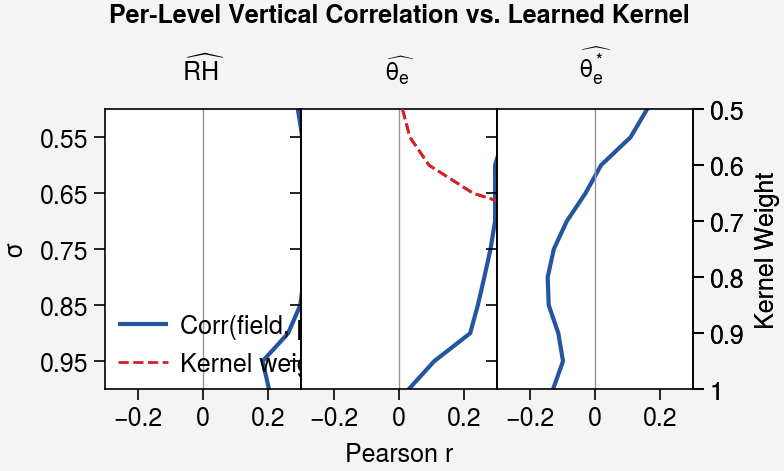

In [14]:
# Goal: What vertical structure does the NN learn, and is it physically meaningful?
VARLABELS = {
    'rh': r'$\widehat{\mathrm{RH}}$',
    'thetae': r'$\widehat{\theta_e}$',
    'thetaestar': r'$\widehat{\theta_e^*}$'}

obs = obsflat[valid]
fig, axs = pplt.subplots(ncols=len(FIELDVARS), figwidth=4, refheight=1.4,
                          share=True, space=0)
axs.format(grid=False, collabels=[VARLABELS[v] for v in FIELDVARS],
           ylabel=r'$\sigma$', ylim=(1, 0.5),
           yticks=[0.95, 0.85, 0.75, 0.65, 0.55])

for col, varkey in enumerate(FIELDVARS):
    ax = axs[col]
    if col != 0:
        ax.tick_params(axis='y', left=False, labelleft=False)

    corrs = np.zeros(nsig)
    for s in range(nsig):
        x = fields[valid, col, s]
        m = np.isfinite(x) & np.isfinite(obs)
        if m.sum() > 100:
            corrs[s] = np.corrcoef(x[m], obs[m])[0, 1]

    ax.plot(corrs, sig, color='#2355a1', linewidth=1.5)
    ax.axvline(0, color='gray', linewidth=0.5)

    if kmean is not None:
        dax = ax.twinx()
        dax.plot(kmean[col], sig, color='#D42028', linewidth=1, linestyle='--')
        dax.format(ylim=(1, 0.5))
        if col == len(FIELDVARS) - 1:
            dax.format(ylabel='Kernel Weight')
        else:
            dax.tick_params(axis='y', right=False, labelright=False)
    ax.format(xlabel='Pearson r', xlim=(-0.3, 0.3), xticks=0.2)

handles = [Line2D([], [], color='#2355a1', linewidth=1.5, label='Corr(field, precip)')]
if kmean is not None:
    handles.append(Line2D([], [], color='#D42028', linewidth=1, linestyle='--',
                           label='Kernel weight'))
axs[0].legend(handles, loc='ll', ncols=1, frame=False)
fig.format(suptitle='Per-Level Vertical Correlation vs. Learned Kernel')
pplt.show()
fig.save('../figs/fig_eval_9.jpg')

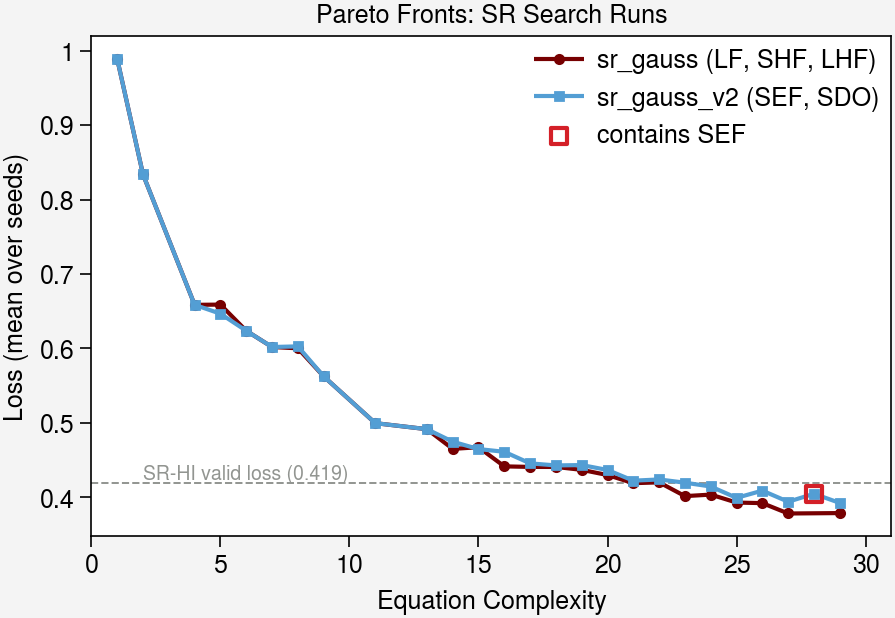

In [15]:
# Goal: Can we improve SR with different inputs or search settings?
pareto_gauss = load_pareto('sr_gauss')
pareto_v2    = load_pareto('sr_gauss_v2')

paretos = {}
if pareto_gauss is not None:
    paretos['sr_gauss'] = pareto_gauss
if pareto_v2 is not None:
    paretos['sr_gauss_v2'] = pareto_v2

if paretos:
    fig, ax = pplt.subplots(refwidth=4, refheight=2.5)

    if 'sr_gauss' in paretos:
        p = paretos['sr_gauss']
        ax.plot(p['complexity'], p['loss'], color=COLORS.get('sr_hi', '#2355a1'),
                linewidth=1.5, marker='o', markersize=3,
                label='sr_gauss (LF, SHF, LHF)', zorder=3)
    if 'sr_gauss_v2' in paretos:
        p = paretos['sr_gauss_v2']
        ax.plot(p['complexity'], p['loss'], color='#539ed4',
                linewidth=1.5, marker='s', markersize=3,
                label='sr_gauss_v2 (SEF, SDO)', zorder=3)
        sef_mask = np.array(['sef' in str(eq) for eq in p['equation']])
        sdo_mask = np.array(['sdo' in str(eq) for eq in p['equation']])
        if sef_mask.any():
            ax.scatter(p.loc[sef_mask, 'complexity'], p.loc[sef_mask, 'loss'],
                       marker='s', s=30, facecolors='none', edgecolors='#D42028',
                       linewidths=1.5, label='contains SEF', zorder=4)
        if sdo_mask.any():
            ax.scatter(p.loc[sdo_mask, 'complexity'], p.loc[sdo_mask, 'loss'],
                       marker='D', s=25, facecolors='none', edgecolors='#F2C85E',
                       linewidths=1.5, label='contains SDO', zorder=4)

    opt_path = os.path.join(MODELSDIR, 'sr', 'optimized_equations.csv')
    if os.path.exists(opt_path):
        opt = pd.read_csv(opt_path)
        hiloss = opt.loc[opt['name'] == 'sr_hi', 'valid_loss'].values
        if len(hiloss):
            ax.axhline(hiloss[0], color='gray', linewidth=0.7, linestyle='--', zorder=1)
            ax.text(2, hiloss[0] + 0.005, f'SR-HI valid loss ({hiloss[0]:.3f})',
                    fontsize=7, color='gray')

    ax.format(grid=False, xlabel='Equation Complexity',
              ylabel='Loss (mean over seeds)',
              title='Pareto Fronts: SR Search Runs', xlim=(0, 31))
    ax.legend(loc='ur', ncols=1, frame=False)
    pplt.show()
    fig.save('../figs/fig_eval_10.jpg')
else:
    print('No Pareto CSV files found')